In [1]:
# sw-neutral-main.ipynb

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import anndata as ad
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import sys

In [4]:
in_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/snp/base/sw-neutral/pp"
out_stat_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/snp/analysis/baf_pre_phasing/stats"
out_fig_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/snp/analysis/baf_pre_phasing/figures"

In [5]:
utils_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/snp/base/scripts"
sys.path.append(utils_dir)
from ubase import *
from ubaf import *
from urdr import stat_stack_zeroprop, stat_LR

In [6]:
os.makedirs(out_stat_dir, exist_ok = True)
os.makedirs(out_fig_dir, exist_ok = True)

In [7]:
cw_prefix = 'cw-'
sw_prefix = 'sw-'

dpi = 300

In [8]:
blue = '#0072B2'
orange = '#E69F00'
green = '#009E73'
red = '#D55E00'     # Vermillion

def_color = blue

In [9]:
tool_labels = ['seed_N', 'stCNASim-rs_N', 'scReadSim-cna_N', 'stCNASim-rs_T', 'scReadSim-cna_T']
tool_palette = {
    'seed_N': orange,
    'stCNASim-rs_N': '#56B4E9',
    'scReadSim-cna_N': green,
    'stCNASim-rs_T': '#F0E442',
    'scReadSim-cna_T': blue
}

# Load Data

In [10]:
seed_normal_fn = os.path.join(in_dir, "seed_normal.h5ad")
rs_normal_fn = os.path.join(in_dir, "rs_normal.h5ad")
rs_tumor_fn = os.path.join(in_dir, "rs_tumor.h5ad")
scrs_normal_fn = os.path.join(in_dir, "scrs_normal.h5ad")
scrs_tumor_fn = os.path.join(in_dir, "scrs_tumor.h5ad")

In [11]:
seed_normal = ad.read_h5ad(seed_normal_fn)
print(seed_normal)

rs_normal = ad.read_h5ad(rs_normal_fn)
print(rs_normal)

rs_tumor = ad.read_h5ad(rs_tumor_fn)
print(rs_tumor)

scrs_normal = ad.read_h5ad(scrs_normal_fn)
print(scrs_normal)

scrs_tumor = ad.read_h5ad(scrs_tumor_fn)
print(scrs_tumor)

AnnData object with n_obs × n_vars = 600 × 7381
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1', 'feature'
    layers: 'AD', 'AD_pre_phase', 'DP', 'OTH'
AnnData object with n_obs × n_vars = 600 × 7381
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1', 'feature'
    layers: 'AD', 'AD_pre_phase', 'DP', 'OTH'
AnnData object with n_obs × n_vars = 600 × 7381
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1', 'feature'
    layers: 'AD', 'AD_pre_phase', 'DP', 'OTH'
AnnData object with n_obs × n_vars = 600 × 7381
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1', 'feature'
    layers: 'AD', 'AD_pre_phase', 'DP'

## Use raw AD instead phased AD

In [12]:
for adata in [seed_normal, rs_normal, scrs_normal, rs_tumor, scrs_tumor]:
    adata.layers['AD_phased'] = adata.layers['AD']
    adata.layers['AD'] = adata.layers['AD_pre_phase']

# Gene-wise Metrics

In [13]:
mv = get_snp_metrics_group(
    adata_lst = [seed_normal, rs_normal, scrs_normal, rs_tumor, scrs_tumor],
    X_names = tool_labels,
    id_lst = [seed_normal.var['feature'].to_numpy(), rs_normal.var['feature'].to_numpy(), scrs_normal.var['feature'].to_numpy(),
             rs_tumor.var['feature'].to_numpy(), scrs_tumor.var['feature'].to_numpy()],
    metrics = ["mean", "var", "cv", "zero_prop", "sum"]
)
mv = mv.rename(columns = dict(X_name = 'group'))
mv

,mean,var,cv,zero_prop,sum,group,feature,DP,AD,baf
0,0.000000,0.000000,0.000000,1.000000,0,seed_N,1:840279,0,0,NaN
1,0.010000,0.009900,9.949874,0.990000,6,seed_N,1:996128,6,6,1.000000
2,0.178333,0.166531,2.288308,0.831667,107,seed_N,1:1217251,107,51,0.476636
3,0.010000,0.009900,9.949874,0.990000,6,seed_N,1:1468636,6,2,0.333333
4,0.010000,0.013233,11.503623,0.991667,6,seed_N,1:1719368,6,4,0.666667
...,...,...,...,...,...,...,...,...,...,...
36900,0.000000,0.000000,0.000000,1.000000,0,scReadSim-cna_T,9:136862025,0,0,NaN
36901,0.011667,0.011531,9.204036,0.988333,7,scReadSim-cna_T,9:136954236,7,0,0.000000
36902,0.145000,0.140642,2.586360,0.863333,87,scReadSim-cna_T,9:137273425,87,0,0.000000
36903,0.016667,0.016389,7.681146,0.983333,10,scReadSim-cna_T,9:137273533,10,0,0.000000


In [14]:
tmp = mv.copy()

tmp.to_csv(
    os.path.join(out_stat_dir, sw_prefix + "metric_values.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

In [15]:
np.log10(mv['mean'].min() + 1), np.log10(mv['mean'].max() + 1)

(0.0, 2.2038846760769406)

In [16]:
np.log10(mv['DP'].min() + 1), np.log10(mv['DP'].max() + 1)

(0.0, 4.9793161426179)

## Single Metric

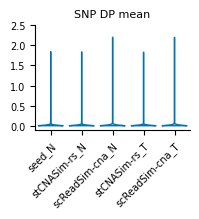

In [17]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv['group']
y = mv['mean']
y = np.log10(y + 1)
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = None,
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 0.5, 1, 1.5, 2, 2.5])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"SNP DP mean", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, sw_prefix + "DP-mean.png")
fig.savefig(fn, dpi = 300)

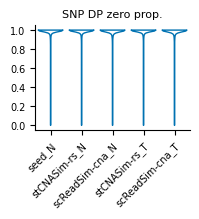

In [18]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv['group']
y = mv['zero_prop']
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = None,
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"SNP DP zero prop.", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, sw_prefix + "DP-zero_prop.png")
fig.savefig(fn, dpi = 300)

### Percentage of genes within specific ranges of zero proportions

In [19]:
st_zeroprop = stat_stack_zeroprop(
    data = mv, 
    metric = "zero_prop",
    group = "group", 
    cutoffs = [.9, .99, 1.01], 
    labels = ["[0, 0.9)", "[0.9, 0.99)", "[0.99, 1]"]
)
print(st_zeroprop)


tmp = st_zeroprop[["group", "cutoff", "label", "percent"]]
tmp.to_csv(
    os.path.join(out_stat_dir, sw_prefix + "DP-perc-of-snps-on-zero_prop.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

              group  level_1  cutoff        label    percent
0            seed_N        0    0.90     [0, 0.9)   4.552229
1            seed_N        1    0.99  [0.9, 0.99)  18.086980
2            seed_N        2    1.01    [0.99, 1]  77.360791
3     stCNASim-rs_N        0    0.90     [0, 0.9)   4.511584
4     stCNASim-rs_N        1    0.99  [0.9, 0.99)  17.978594
5     stCNASim-rs_N        2    1.01    [0.99, 1]  77.509823
6   scReadSim-cna_N        0    0.90     [0, 0.9)   5.378675
7   scReadSim-cna_N        1    0.99  [0.9, 0.99)  18.913426
8   scReadSim-cna_N        2    1.01    [0.99, 1]  75.707899
9     stCNASim-rs_T        0    0.90     [0, 0.9)   4.511584
10    stCNASim-rs_T        1    0.99  [0.9, 0.99)  17.883756
11    stCNASim-rs_T        2    1.01    [0.99, 1]  77.604661
12  scReadSim-cna_T        0    0.90     [0, 0.9)   5.419320
13  scReadSim-cna_T        1    0.99  [0.9, 0.99)  19.197941
14  scReadSim-cna_T        2    1.01    [0.99, 1]  75.382739


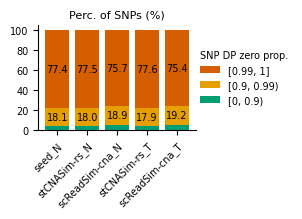

In [20]:
data = st_zeroprop
x, y, hue = 'group', 'percent', 'label'
min_v = 10
font_size = 7
colors = [green, orange, red]

# prepare data.
df = long2wide(data, index = x, columns = hue, values = y)
df[x] = df.index
hue_groups = data[hue].unique()
cumsum = np.array([0.0] * df.shape[0])

# plot.
fig = plt.figure(figsize = (3.1, 2.3))

for i, h in enumerate(hue_groups):
    if i == 0:
        plt.bar(df[x], df[h], label = h, color = colors[i])
    else:
        ax = plt.gca()
        ax.bar(df[x], df[h], label = h, bottom = cumsum, color = colors[i])
    cumsum += df[h]
        
for c in ax.containers:
    labels = [str(round(v.get_height(), 1))    \
                if v.get_height() > min_v else '' for v in c]
    ax.bar_label(c, label_type = 'center', labels = labels, 
                    fontsize = font_size, color = 'black')

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_ylabel("")
ax.set_xlabel("")

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles = handles[::-1],
    labels = labels[::-1],
    title = "SNP DP zero prop.",
    loc = 'center left',
    bbox_to_anchor = [0.97, 0.5],
    title_fontsize = font_size,
    fontsize = font_size,
    alignment = 'left',
    frameon = False
)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Perc. of SNPs (%)", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, sw_prefix + "DP-perc-of-snps-on-zero_prop.png")
fig.savefig(fn, dpi = 300)

### BAF

In [21]:
mv_ind, idx_ind = remove_nan_baf(mv, how = 'independent')
print(mv_ind)

           mean       var         cv  zero_prop  sum            group  \
1      0.010000  0.009900   9.949874   0.990000    6           seed_N   
2      0.178333  0.166531   2.288308   0.831667  107           seed_N   
3      0.010000  0.009900   9.949874   0.990000    6           seed_N   
4      0.010000  0.013233  11.503623   0.991667    6           seed_N   
5      0.006667  0.009956  14.966629   0.995000    4           seed_N   
...         ...       ...        ...        ...  ...              ...   
36897  0.016667  0.016389   7.681146   0.983333   10  scReadSim-cna_T   
36899  0.040000  0.038400   4.898979   0.960000   24  scReadSim-cna_T   
36901  0.011667  0.011531   9.204036   0.988333    7  scReadSim-cna_T   
36902  0.145000  0.140642   2.586360   0.863333   87  scReadSim-cna_T   
36903  0.016667  0.016389   7.681146   0.983333   10  scReadSim-cna_T   

           feature   DP  AD       baf  
1         1:996128    6   6  1.000000  
2        1:1217251  107  51  0.476636  
3  

In [22]:
tmp = mv_ind.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, sw_prefix + "metric_values-filter_nan_independent.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

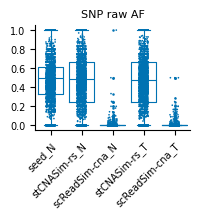

In [23]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv_ind['group']
y = mv_ind['baf']
ax = sns.boxplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    showfliers = True,
    fliersize = 0.8,
    linewidth = 0.8
)
sns.stripplot(
    x = x, y = y, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False, 
    ax = ax,
    size = 1.2, 
    jitter = 0.15
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"SNP raw AF", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, sw_prefix + "baf.png")
fig.savefig(fn, dpi = 300)

## Linear Regression

In [24]:
pairs = [
    ("stCNASim-rs_N", "seed_N"),
    ("scReadSim-cna_N", "seed_N"),
    ("stCNASim-rs_N", "scReadSim-cna_N"),
    ("stCNASim-rs_T", "scReadSim-cna_T")
]

selected_gvars = pd.DataFrame(data = dict(
    x = [p[1] for p in pairs],
    y = [p[0] for p in pairs],
))

In [25]:
mv_isec, idx_isec = remove_nan_baf(mv, how = 'intersect')
print(mv_isec)


tmp = mv_isec.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, sw_prefix + "metric_values-filter_nan_intersect.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

           mean       var         cv  zero_prop  sum            group  \
1      0.010000  0.009900   9.949874   0.990000    6           seed_N   
2      0.178333  0.166531   2.288308   0.831667  107           seed_N   
3      0.010000  0.009900   9.949874   0.990000    6           seed_N   
4      0.010000  0.013233  11.503623   0.991667    6           seed_N   
5      0.006667  0.009956  14.966629   0.995000    4           seed_N   
...         ...       ...        ...        ...  ...              ...   
36897  0.016667  0.016389   7.681146   0.983333   10  scReadSim-cna_T   
36899  0.040000  0.038400   4.898979   0.960000   24  scReadSim-cna_T   
36901  0.011667  0.011531   9.204036   0.988333    7  scReadSim-cna_T   
36902  0.145000  0.140642   2.586360   0.863333   87  scReadSim-cna_T   
36903  0.016667  0.016389   7.681146   0.983333   10  scReadSim-cna_T   

           feature   DP  AD       baf  
1         1:996128    6   6  1.000000  
2        1:1217251  107  51  0.476636  
3  

In [26]:
st_lr = stat_LR(
    data = mv_isec,
    metric = "baf", group = "group", gvars = selected_gvars, 
    log_scale = True
)
print(st_lr)

tmp = st_lr.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, sw_prefix + "baf-lr-stat.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

                 x                y         a         b        r2   p_value
0           seed_N    stCNASim-rs_N  0.991121 -0.001042  0.613918  0.000000
1           seed_N  scReadSim-cna_N -0.002502  0.001241  0.000689  0.162638
2  scReadSim-cna_N    stCNASim-rs_N -0.587971  0.160395  0.001964  0.018339
3  scReadSim-cna_T    stCNASim-rs_T -0.366194  0.158701  0.001028  0.088068


In [27]:
df_baf = long2wide(mv_isec, columns = 'group', values = 'baf', index = 'feature')
print(df_baf)

tmp = df_baf.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, sw_prefix + "baf-lr.tsv"), 
    header = True, 
    index = True, 
    sep = "\t"
)

group          seed_N  stCNASim-rs_N  scReadSim-cna_N  stCNASim-rs_T  \
feature                                                                
1:996128     1.000000       1.000000              0.0       1.000000   
1:1217251    0.476636       0.511905              0.0       0.416667   
1:1468636    0.333333       0.000000              0.0       0.000000   
1:1719368    0.666667       0.500000              0.0       0.500000   
1:1719406    0.500000       0.333333              0.0       0.333333   
...               ...            ...              ...            ...   
9:136723831  0.500000       0.200000              0.0       0.642857   
9:136724914  0.437500       0.352941              0.0       0.538462   
9:136954236  0.333333       0.000000              0.0       0.000000   
9:137273425  0.651163       0.714286              0.0       0.620253   
9:137273533  0.545455       0.500000              0.0       0.714286   

group        scReadSim-cna_T  
feature                       
1

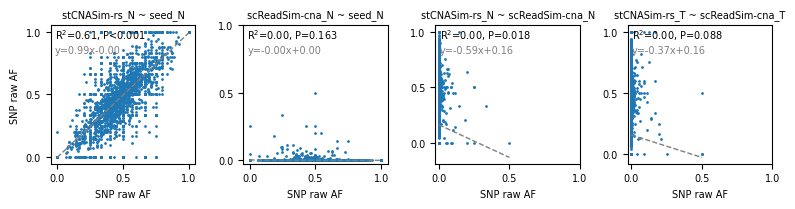

In [28]:
ncols = 4
fig, axs = plt.subplots(nrows = 1, ncols = ncols, figsize = (8.0, 2.2))

pos_r = (.03, .9)
pos_fit = (.03, .8)
fit_kws = dict()
fontsize = 7

columns = np.asarray(df_baf.columns)
df = df_baf[columns].copy()

gvars = st_lr[['x', 'y']].copy()
k = 0
for i in range(gvars.shape[0]):
    ax = axs.flat[k]
    cx = gvars['x'].loc[i]
    cy = gvars['y'].loc[i]
    d = st_lr.loc[(st_lr['x'] == cx) & (st_lr['y'] == cy)]
    assert d.shape[0] == 1
    a = d['a'].iloc[0]
    b = d['b'].iloc[0]
    r2 = d['r2'].iloc[0]
    p_value = d['p_value'].iloc[0]

    x, y = df[cx], df[cy]
    ax.plot(x, y, marker = '.', markersize = 2, linestyle = 'none')
    x_vals = np.linspace(max(ax.get_xlim()[0], np.min(x)), 
                        min(ax.get_xlim()[1], np.max(x)), 100)

    color_fit = fit_kws.get('color', 'gray')
    ax.plot(
        x_vals, a*x_vals+b, 
        linestyle = fit_kws.get('linestyle', '--'), 
        color = color_fit, 
        linewidth = fit_kws.get('linewidth', 1.0)
    )
    equation_str = format_equation(a, b)
    ax.annotate(equation_str, xy = pos_fit, xycoords = ax.transAxes,
                color = color_fit, fontsize = fontsize)
    pv_str = format_pvalue(p_value) 
    ax.annotate(r"R$^2$=%.2f, %s" % (r2, pv_str), xy = pos_r, 
                xycoords = ax.transAxes, fontsize = fontsize)

    ax.set_title(None)
    ax.set_xlabel("SNP raw AF", fontsize = fontsize)
    if k % ncols == 0:
        ax.set_ylabel("SNP raw AF", fontsize = fontsize)
    ax.set_title(cy + ' ~ ' + cx, fontsize = fontsize)
    ax.set_xticks([0, 0.5, 1])
    ax.set_xticklabels(
        ax.get_xticklabels(), 
        fontsize = fontsize
    )
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(
        ax.get_yticklabels(), 
        fontsize = fontsize
    )
    k += 1

for ax in axs:
    for s in ["top", "right"]:
        ax.spines[s].set_visible(True)
        
plt.tight_layout()
fn = os.path.join(out_fig_dir, sw_prefix + "baf-lr.png")
fig.savefig(fn, dpi = 300)

### Filter SNPs by DP

In [29]:
#filter_snps = mv.loc[(mv['group'] == 'seed_N') & (mv['DP'] < 10), 'feature']
#print(filter_snps.shape)

#df = mv.loc[~(mv['feature'].isin(filter_snps))].copy()
#print(df.shape)

#mv_isec_DP, idx_isec_DP = remove_nan_baf(df, how = 'intersect')
#print(mv_isec_DP)

In [30]:
filter_snps = mv_isec.loc[mv_isec['DP'] < 10, 'feature']
print(filter_snps.shape)

df = mv_isec.loc[~(mv_isec['feature'].isin(filter_snps))].copy()
mv_isec_DP, idx_isec_DP = remove_nan_baf(df, how = 'intersect')


tmp = mv_isec_DP.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, sw_prefix + "metric_values-filter_nan_intersect-filter_DP.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

(7217,)


In [31]:
st_lr_DP = stat_LR(
    data = mv_isec_DP,
    metric = "baf", group = "group", gvars = selected_gvars, 
    log_scale = True
)
print(st_lr_DP)

tmp = st_lr_DP.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, sw_prefix + "baf-lr-stat-filter_DP.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

                 x                y         a         b        r2  \
0           seed_N    stCNASim-rs_N  1.013229 -0.003231  0.659611   
1           seed_N  scReadSim-cna_N -0.014853  0.003461  0.017636   
2  scReadSim-cna_N    stCNASim-rs_N -0.680906  0.165675  0.003726   
3  scReadSim-cna_T    stCNASim-rs_T -0.603468  0.165823  0.003083   

         p_value  
0  7.386243e-257  
1   1.088284e-05  
2   4.391075e-02  
3   6.688570e-02  


In [32]:
df_baf_DP = long2wide(mv_isec_DP, columns = 'group', values = 'baf', index = 'feature')
print(df_baf_DP)

tmp = df_baf_DP.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, sw_prefix + "baf-lr-filter_DP.tsv"), 
    header = True, 
    index = True, 
    sep = "\t"
)

group          seed_N  stCNASim-rs_N  scReadSim-cna_N  stCNASim-rs_T  \
feature                                                                
1:1217251    0.476636       0.511905         0.000000       0.416667   
1:2189679    0.408000       0.389381         0.000000       0.403509   
1:9268027    0.153846       0.066667         0.000000       0.058824   
1:9848424    0.368421       0.428571         0.027778       0.312500   
1:11054883   0.722222       0.666667         0.000000       0.727273   
...               ...            ...              ...            ...   
9:136672544  0.477528       0.500000         0.000000       0.418848   
9:136673235  0.484594       0.501493         0.004662       0.446875   
9:136723831  0.500000       0.200000         0.000000       0.642857   
9:136724914  0.437500       0.352941         0.000000       0.538462   
9:137273425  0.651163       0.714286         0.000000       0.620253   

group        scReadSim-cna_T  
feature                       
1

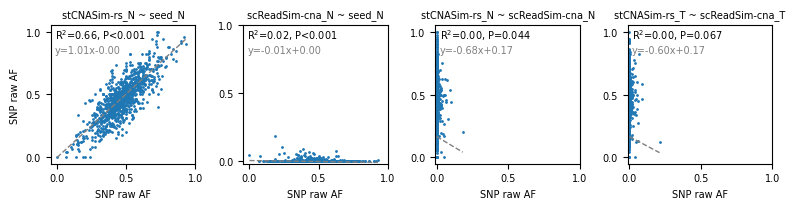

In [33]:
ncols = 4
fig, axs = plt.subplots(nrows = 1, ncols = ncols, figsize = (8.0, 2.2))

pos_r = (.03, .9)
pos_fit = (.03, .8)
fit_kws = dict()
fontsize = 7

columns = np.asarray(df_baf_DP.columns)
df = df_baf_DP[columns].copy()

gvars = st_lr_DP[['x', 'y']].copy()
k = 0
for i in range(gvars.shape[0]):
    ax = axs.flat[k]
    cx = gvars['x'].loc[i]
    cy = gvars['y'].loc[i]
    d = st_lr_DP.loc[(st_lr_DP['x'] == cx) & (st_lr_DP['y'] == cy)]
    assert d.shape[0] == 1
    a = d['a'].iloc[0]
    b = d['b'].iloc[0]
    r2 = d['r2'].iloc[0]
    p_value = d['p_value'].iloc[0]

    x, y = df[cx], df[cy]
    ax.plot(x, y, marker = '.', markersize = 2, linestyle = 'none')
    x_vals = np.linspace(max(ax.get_xlim()[0], np.min(x)), 
                        min(ax.get_xlim()[1], np.max(x)), 100)

    color_fit = fit_kws.get('color', 'gray')
    ax.plot(
        x_vals, a*x_vals+b, 
        linestyle = fit_kws.get('linestyle', '--'), 
        color = color_fit, 
        linewidth = fit_kws.get('linewidth', 1.0)
    )
    equation_str = format_equation(a, b)
    ax.annotate(equation_str, xy = pos_fit, xycoords = ax.transAxes,
                color = color_fit, fontsize = fontsize)
    pv_str = format_pvalue(p_value) 
    ax.annotate(r"R$^2$=%.2f, %s" % (r2, pv_str), xy = pos_r, 
                xycoords = ax.transAxes, fontsize = fontsize)

    ax.set_title(None)
    ax.set_xlabel("SNP raw AF", fontsize = fontsize)
    if k % ncols == 0:
        ax.set_ylabel("SNP raw AF", fontsize = fontsize)
    ax.set_title(cy + ' ~ ' + cx, fontsize = fontsize)
    ax.set_xticks([0, 0.5, 1])
    ax.set_xticklabels(
        ax.get_xticklabels(), 
        fontsize = fontsize
    )
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(
        ax.get_yticklabels(), 
        fontsize = fontsize
    )
    k += 1

for ax in axs:
    for s in ["top", "right"]:
        ax.spines[s].set_visible(True)
        
plt.tight_layout()
fn = os.path.join(out_fig_dir, sw_prefix + "baf-lr-filter_DP.png")
fig.savefig(fn, dpi = 300)

### BAF vs. Mean

In [34]:
selected_gvars = ['seed_N', 'stCNASim-rs_N', 'scReadSim-cna_N', 'stCNASim-rs_T', 'scReadSim-cna_T']

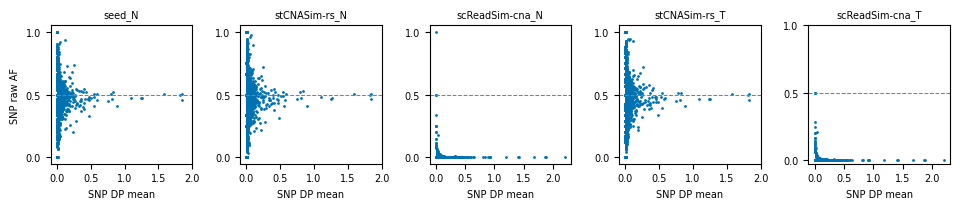

In [35]:
ncols = 5
fig, axs = plt.subplots(nrows = 1, ncols = ncols, figsize = (9.7, 2.2))

fontsize = 7

gvars = selected_gvars
k = 0
for i in range(len(gvars)):
    ax = axs[k]
    cx = gvars[i]
    df = mv_ind.loc[mv_ind['group'] == cx].copy()

    vx = df['mean'].to_numpy()
    vy = df['baf'].to_numpy()
    vx = np.log10(vx + 1)
    
    ax.plot(vx, vy, marker = '.', markersize = 2, 
            linestyle = 'none', color = def_color)

    ref_kws = dict()
    ax.axhline(
        y = ref_kws.get('y', 0.5), 
        linestyle = ref_kws.get('linestyle', '--'), 
        linewidth = ref_kws.get('linewidth', 0.75),
        color = ref_kws.get('color', 'gray')
    )
    ax.set_xticks([0, 0.5, 1, 1.5, 2])
    ax.set_xticklabels(
        ax.get_xticklabels(), 
        fontsize = fontsize
    )
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(
        ax.get_yticklabels(), 
        fontsize = fontsize
    )
    ax.set_xlabel("SNP DP mean", fontsize = fontsize)
    if k % ncols == 0:
        ax.set_ylabel("SNP raw AF", fontsize = fontsize)
    ax.set_title(cx, fontsize = fontsize)
    k += 1

for ax in axs:
    for s in ["top", "right"]:
        ax.spines[s].set_visible(True)
        
plt.tight_layout()
fn = os.path.join(out_fig_dir, sw_prefix + "baf-vs-DP-mean.png")
fig.savefig(fn, dpi = 300)